In [1]:
import pandas as pd

print("1. Downloading & Processing JHU COVID-19 Data...")
jhu_url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
jhu_df = pd.read_csv(jhu_url)

# Melt wide to long
jhu_long = jhu_df.melt(id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'], var_name='Date', value_name='Cases')
jhu_long = jhu_long.rename(columns={'Country/Region': 'Country'})

# Clean and aggregate
jhu_long = jhu_long[['Date', 'Country', 'Cases']]
jhu_long['Cases'] = pd.to_numeric(jhu_long['Cases'], errors='coerce').fillna(0)
jhu_long = jhu_long.groupby(['Country', 'Date'], as_index=False)['Cases'].sum()

# Fix Dates
jhu_long['Date'] = pd.to_datetime(jhu_long['Date'], format='%m/%d/%y', errors='coerce')
jhu_long = jhu_long.dropna(subset=['Date'])
jhu_long = jhu_long.sort_values(by=['Country', 'Date']).reset_index(drop=True)

# Export
jhu_long.to_csv('jhu_cleaned.csv', index=False)
print("-> JHU Data saved as 'jhu_cleaned.csv'")

print("\n2. Downloading OWID Vaccination Data...")
owid_url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/vaccinations/vaccinations.csv"
owid_df = pd.read_csv(owid_url)
owid_df.to_csv('owid_raw.csv', index=False)
print("-> OWID Data saved as 'owid_raw.csv'")

print("\n3. Downloading Google Mobility Data...")
google_url = "https://www.gstatic.com/covid19/mobility/Global_Mobility_Report.csv"
google_df = pd.read_csv(google_url, low_memory=False)
google_df.to_csv('google_raw.csv', index=False)
print("-> Google Mobility Data saved as 'google_raw.csv'")

print("\nALL DOWNLOADS COMPLETE. CHECK YOUR FILES TAB.")

1. Downloading & Processing JHU COVID-19 Data...
-> JHU Data saved as 'jhu_cleaned.csv'

2. Downloading OWID Vaccination Data...
-> OWID Data saved as 'owid_raw.csv'

3. Downloading Google Mobility Data...
-> Google Mobility Data saved as 'google_raw.csv'

ALL DOWNLOADS COMPLETE. CHECK YOUR FILES TAB.


In [3]:
import pandas as pd

print("1. Loading the datasets into memory...")
jhu = pd.read_csv('jhu_cleaned.csv')
owid = pd.read_csv('owid_raw.csv')
google = pd.read_csv('google_raw.csv', low_memory=False)

print("2. Standardizing Columns and Granularity...")
# OWID and Google use different column names for Country and Date. Fix them.
if 'location' in owid.columns:
    owid = owid.rename(columns={'location': 'Country', 'date': 'Date'})
if 'country_region' in google.columns:
    google = google.rename(columns={'country_region': 'Country', 'date': 'Date'})

# CRITICAL FIX: Filter Google data to national level only.
google = google[google['sub_region_1'].isna()].copy()

print("3. Forcing Country Name Alignment...")
country_mapping = {
    'US': 'United States',
    'Korea, South': 'South Korea',
    'Taiwan*': 'Taiwan',
    'Czechia': 'Czech Republic',
    'Russian Federation': 'Russia'
}

jhu['Country'] = jhu['Country'].replace(country_mapping)
owid['Country'] = owid['Country'].replace(country_mapping)
google['Country'] = google['Country'].replace(country_mapping)

# Ensure Date columns are the exact same data type
jhu['Date'] = pd.to_datetime(jhu['Date'])
owid['Date'] = pd.to_datetime(owid['Date'])
google['Date'] = pd.to_datetime(google['Date'])

print("4. Executing the Merge...")
# FIXED: Removed the testing column. We only pull the vaccination rate.
owid_cols = ['Country', 'Date', 'people_fully_vaccinated_per_hundred']
google_cols = [
    'Country', 'Date',
    'retail_and_recreation_percent_change_from_baseline',
    'transit_stations_percent_change_from_baseline',
    'workplaces_percent_change_from_baseline'
]

# Merge JHU with OWID, then merge the result with Google Mobility
master_df = pd.merge(jhu, owid[owid_cols], on=['Country', 'Date'], how='left')
master_df = pd.merge(master_df, google[google_cols], on=['Country', 'Date'], how='left')

# Sort chronologically and export
master_df = master_df.sort_values(['Country', 'Date']).reset_index(drop=True)
master_df.to_csv('master_merged_data.csv', index=False)

print(f"MERGE COMPLETE. Final dataset size: {master_df.shape[0]} rows and {master_df.shape[1]} columns.")
print("-> Saved as 'master_merged_data.csv'")

1. Loading the datasets into memory...
2. Standardizing Columns and Granularity...
3. Forcing Country Name Alignment...
4. Executing the Merge...
MERGE COMPLETE. Final dataset size: 290736 rows and 7 columns.
-> Saved as 'master_merged_data.csv'


In [4]:
import pandas as pd
import numpy as np

print("1. Loading merged dataset...")
df = pd.read_csv('master_merged_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Country', 'Date']).reset_index(drop=True)

print("2. The Cumulative Trap: Calculating Daily New Cases...")
# JHU data is cumulative. We must find the daily difference.
# We use clip(lower=0) because some countries did bulk negative corrections to their data.
df['Daily_New_Cases'] = df.groupby('Country')['Cases'].diff().clip(lower=0)

print("3. Smoothing Data & Defining the Target...")
# 7-day rolling average of daily new cases to fix weekend reporting dumps
df['Cases_7d_avg'] = df.groupby('Country')['Daily_New_Cases'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())

# Calculate Week-over-Week growth (Current 7d avg / 7d avg from 7 days ago)
df['Cases_7d_avg_last_week'] = df.groupby('Country')['Cases_7d_avg'].shift(7)

# Avoid division by zero errors mathematically
df['WoW_Growth'] = np.where(df['Cases_7d_avg_last_week'] > 0,
                            df['Cases_7d_avg'] / df['Cases_7d_avg_last_week'],
                            0)

# The Target Definition: >1.5x growth AND absolute cases > 50
df['Hotspot'] = np.where((df['WoW_Growth'] > 1.5) & (df['Cases_7d_avg'] > 50), 1, 0)

print("4. Engineering Biological Lags...")
# 14-day lag for mobility: If people stop going to transit stations today, cases drop 14 days from now.
mobility_cols = [col for col in df.columns if 'percent_change' in col]
for col in mobility_cols:
    df[f'{col}_Lag_14d'] = df.groupby('Country')[col].shift(14)

# 21-day lag for vaccinations: Immunity takes time to build.
if 'people_fully_vaccinated_per_hundred' in df.columns:
    df['Vax_Lag_21d'] = df.groupby('Country')['people_fully_vaccinated_per_hundred'].shift(21)

print("5. Exporting ML-Ready Dataset...")
df.to_csv('ml_ready_dataset.csv', index=False)

# Reality Check
hotspot_count = df['Hotspot'].sum()
total_rows = len(df)
print(f"-> Total Rows: {total_rows}")
print(f"-> Total Hotspot Instances Identified: {hotspot_count} ({(hotspot_count/total_rows)*100:.2f}%)")
print("-> Saved as 'ml_ready_dataset.csv'")

1. Loading merged dataset...
2. The Cumulative Trap: Calculating Daily New Cases...
3. Smoothing Data & Defining the Target...
4. Engineering Biological Lags...
5. Exporting ML-Ready Dataset...
-> Total Rows: 290736
-> Total Hotspot Instances Identified: 20192 (6.95%)
-> Saved as 'ml_ready_dataset.csv'


In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score
import xgboost as xgb

print("1. Loading ML-Ready Dataset...")
df = pd.read_csv('ml_ready_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("2. Handling Biological Realities (Imputing & Cleaning)...")
# Vaccines didn't exist early in the pandemic. NaN means 0%.
if 'Vax_Lag_21d' in df.columns:
    df['Vax_Lag_21d'] = df['Vax_Lag_21d'].fillna(0)

features = [
    'retail_and_recreation_percent_change_from_baseline_Lag_14d',
    'transit_stations_percent_change_from_baseline_Lag_14d',
    'workplaces_percent_change_from_baseline_Lag_14d'
]
if 'Vax_Lag_21d' in df.columns:
    features.append('Vax_Lag_21d')

target = 'Hotspot'

# Drop rows where mobility data is missing (we cannot guess human movement)
ml_df = df.dropna(subset=features + [target]).copy()

print("3. Executing Chronological Split (No Time Travel)...")
ml_df = ml_df.sort_values('Date')

# 80% Train, 20% Test based strictly on time
split_idx = int(len(ml_df) * 0.8)
train = ml_df.iloc[:split_idx]
test = ml_df.iloc[split_idx:]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

print(f"-> Training on {len(X_train)} historical records...")
print(f"-> Testing on {len(X_test)} future records...")

print("\n4. Training XGBoost Classifier...")
# We must heavily penalize the model for missing hotspots.
# Calculate class weight dynamically based on the 7% imbalance.
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_weight, # This forces the model to care about the minority class
    random_state=42,
    eval_metric='auc'
)

model.fit(X_train, y_train)

print("\n5. Evaluating Model on Future Data...")
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
recall = tp / (tp + fn)
fnr = fn / (tp + fn)
roc_auc = roc_auc_score(y_test, y_prob)

print("-" * 50)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"True Hotspots Caught (Recall): {recall*100:.2f}%")
print(f"Real Hotspots Missed (False Negative Rate): {fnr*100:.2f}%")
print("-" * 50)
print("Confusion Matrix:")
print(f"True Negatives (Safe correctly predicted):  {tn}")
print(f"False Positives (False Alarms):             {fp}")
print(f"False Negatives (Missed Outbreaks):         {fn}")
print(f"True Positives (Hotspots Caught):           {tp}")
print("-" * 50)

# Save the model for the dashboard tomorrow
model.save_model("xgb_hotspot_model.json")
print("-> Model saved as 'xgb_hotspot_model.json'")

1. Loading ML-Ready Dataset...
2. Handling Biological Realities (Imputing & Cleaning)...
3. Executing Chronological Split (No Time Travel)...
-> Training on 145066 historical records...
-> Testing on 36267 future records...

4. Training XGBoost Classifier...

5. Evaluating Model on Future Data...
--------------------------------------------------
ROC-AUC Score: 0.5706
True Hotspots Caught (Recall): 47.60%
Real Hotspots Missed (False Negative Rate): 52.40%
--------------------------------------------------
Confusion Matrix:
True Negatives (Safe correctly predicted):  21346
False Positives (False Alarms):             12461
False Negatives (Missed Outbreaks):         1289
True Positives (Hotspots Caught):           1171
--------------------------------------------------
-> Model saved as 'xgb_hotspot_model.json'


In [6]:
!pip install shap

1. Loading Model and Data...
2. Initializing SHAP Explainer (Sampling for speed)...
3. Generating Feature Importance Biological Insight...

--- BIOLOGICAL DRIVERS OF HOTSPOTS ---
                                                   Feature  Impact_on_Prediction
                                               Vax_Lag_21d              0.440711
retail_and_recreation_percent_change_from_baseline_Lag_14d              0.367759
     transit_stations_percent_change_from_baseline_Lag_14d              0.249734
           workplaces_percent_change_from_baseline_Lag_14d              0.192668
--------------------------------------

-> SHAP visual saved as 'shap_summary.png'. Download this for your presentation.


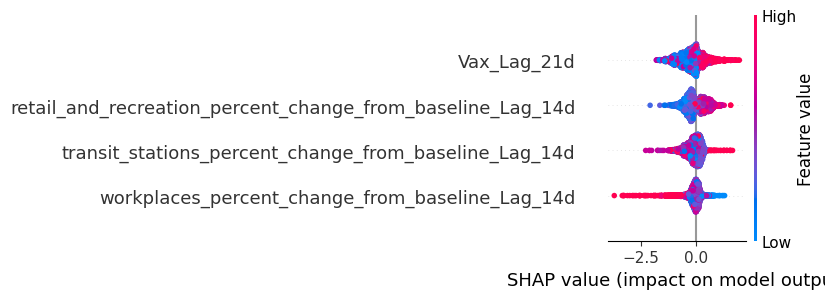

In [7]:
import shap
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

print("1. Loading Model and Data...")
model = xgb.XGBClassifier()
model.load_model("xgb_hotspot_model.json")

df = pd.read_csv('ml_ready_dataset.csv')
features = [
    'retail_and_recreation_percent_change_from_baseline_Lag_14d',
    'transit_stations_percent_change_from_baseline_Lag_14d',
    'workplaces_percent_change_from_baseline_Lag_14d',
    'Vax_Lag_21d'
]
ml_df = df.dropna(subset=features + ['Hotspot']).copy()

# Chronological split to match training
ml_df = ml_df.sort_values('Date')
split_idx = int(len(ml_df) * 0.8)
X_train = ml_df.iloc[:split_idx][features]

print("2. Initializing SHAP Explainer (Sampling for speed)...")
# We sample 5,000 rows so Colab doesn't crash or take an hour
X_sample = shap.utils.sample(X_train, 5000)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print("3. Generating Feature Importance Biological Insight...")
# Calculate mean absolute SHAP values for each feature
mean_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': features,
    'Impact_on_Prediction': mean_shap
}).sort_values(by='Impact_on_Prediction', ascending=False)

print("\n--- BIOLOGICAL DRIVERS OF HOTSPOTS ---")
print(importance_df.to_string(index=False))
print("--------------------------------------")

# Generate the visual plot and save it
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.savefig('shap_summary.png', bbox_inches='tight')
print("\n-> SHAP visual saved as 'shap_summary.png'. Download this for your presentation.")

In [8]:
%%writefile app.py
import streamlit as st
import pandas as pd
import xgboost as xgb
import plotly.express as px

# 1. Page Config
st.set_page_config(page_title="Epidemic Spread Simulator", layout="wide")
st.title("🌍 Global Epidemic Risk Simulator")
st.markdown("Adjust the policy levers on the left to simulate interventions and predict hotspot probabilities 14 days into the future.")

# 2. Load Model & Data
@st.cache_resource
def load_system():
    model = xgb.XGBClassifier()
    model.load_model("xgb_hotspot_model.json")
    df = pd.read_csv('ml_ready_dataset.csv')
    return model, df

model, df = load_system()

# Get the most recent data snapshot for all countries
latest_date = df['Date'].max()
current_data = df[df['Date'] == latest_date].copy()

# 3. Sidebar - The Policy Simulator
st.sidebar.header("Policy Interventions (14-21 Day Lags)")

vax_sim = st.sidebar.slider("Simulate Vaccination Rate (%)", 0.0, 100.0, 50.0)
retail_sim = st.sidebar.slider("Simulate Retail Mobility (% Change)", -100, 50, 0)
transit_sim = st.sidebar.slider("Simulate Transit Mobility (% Change)", -100, 50, 0)
work_sim = st.sidebar.slider("Simulate Workplace Mobility (% Change)", -100, 50, 0)

# 4. Apply Simulations to Data
simulated_data = current_data.copy()
simulated_data['Vax_Lag_21d'] = vax_sim
simulated_data['retail_and_recreation_percent_change_from_baseline_Lag_14d'] = retail_sim
simulated_data['transit_stations_percent_change_from_baseline_Lag_14d'] = transit_sim
simulated_data['workplaces_percent_change_from_baseline_Lag_14d'] = work_sim

features = [
    'retail_and_recreation_percent_change_from_baseline_Lag_14d',
    'transit_stations_percent_change_from_baseline_Lag_14d',
    'workplaces_percent_change_from_baseline_Lag_14d',
    'Vax_Lag_21d'
]

# 5. Generate Predictions
probabilities = model.predict_proba(simulated_data[features])[:, 1]
simulated_data['Hotspot_Probability'] = probabilities * 100

# 6. Render the Risk Map
fig = px.choropleth(
    simulated_data,
    locations="Country",
    locationmode='country names',
    color="Hotspot_Probability",
    hover_name="Country",
    color_continuous_scale=px.colors.sequential.Reds,
    range_color=[0, 100],
    title=f"Predicted Hotspot Probability Map (Simulated)"
)
fig.update_layout(geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'))

st.plotly_chart(fig, use_container_width=True)

st.markdown("---")
st.markdown("**Biological Interpretation:** Model optimized for false-negative reduction. Note that vaccination rates heavily interact with local testing infrastructure limits.")

Writing app.py


In [10]:
!npm install localtunnel
!streamlit run app.py &>/content/logs.txt &
import urllib
print("Password/Enpoint IP for localtunnel is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n"))
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴
up to date, audited 23 packages in 890ms
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠦Password/Enpoint IP for localtunnel is: 34.48.100.151
⠙your url is: https://fine-terms-turn.loca.lt
^C


In [12]:
!cat /content/logs.txt

/bin/bash: line 1: streamlit: command not found


In [13]:
# 1. Install the missing libraries (Quietly so it doesn't spam your screen)
!pip install -q streamlit plotly

# 2. Launch Streamlit in the background
!nohup streamlit run app.py &>/content/logs.txt &

# 3. Wait 3 seconds for it to boot
import time
time.sleep(3)

# 4. Get the Localtunnel Password (IP Address)
import urllib
ip_address = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n")
print("--------------------------------------------------")
print(f"YOUR PASSWORD / ENDPOINT IP IS: {ip_address}")
print("--------------------------------------------------")

# 5. Launch the Tunnel
!npx localtunnel --port 8501

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 39.1 MB/s eta 0:00:00
--------------------------------------------------
YOUR PASSWORD / ENDPOINT IP IS: 34.48.100.151
--------------------------------------------------
⠙your url is: https://new-pears-sit.loca.lt
^C


In [14]:
!nohup streamlit run app.py &>/content/logs.txt &

In [15]:
# 3. Wait 3 seconds for it to boot
import time
time.sleep(3)

# 4. Get the Localtunnel Password (IP Address)
import urllib
ip_address = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n")
print("--------------------------------------------------")
print(f"YOUR PASSWORD / ENDPOINT IP IS: {ip_address}")
print("--------------------------------------------------")

# 5. Launch the Tunnel
!npx localtunnel --port 8501

--------------------------------------------------
YOUR PASSWORD / ENDPOINT IP IS: 34.48.100.151
--------------------------------------------------
⠙⠹your url is: https://forty-drinks-draw.loca.lt
^C


In [16]:
!pip install pyngrok -q
from pyngrok import ngrok
import time

print("1. Terminating old broken tunnels...")
ngrok.kill()

print("2. Authenticating Ngrok...")
# PASTE YOUR TOKEN INSIDE THE QUOTES BELOW
ngrok.set_auth_token("3BlgEXnoJZWoFVzozJ4lEftzTU8_4FqywyQSNjwpY61q4LK3Y")

print("3. Ensuring Streamlit is running...")
!nohup streamlit run app.py &>/content/logs.txt &
time.sleep(3)

print("4. Opening stable tunnel...")
public_url = ngrok.connect(8501)
print("--------------------------------------------------")
print(f"YOUR STABLE DASHBOARD URL: {public_url}")
print("--------------------------------------------------")

1. Terminating old broken tunnels...
2. Authenticating Ngrok...
3. Ensuring Streamlit is running...
4. Opening stable tunnel...
--------------------------------------------------
YOUR STABLE DASHBOARD URL: NgrokTunnel: "https://matted-unfurbelowed-benson.ngrok-free.dev" -> "http://localhost:8501"
--------------------------------------------------
